In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

from src.DriftCorrectionFunctions import (
    Drift_Correction_Functions,
    DriftMethod,
    DriftParameters,
    DriftResult,
)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [3]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [4]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [37]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260122_6ColourQDot/MixD"

In [32]:
metadata_files = H_F.file_search(image_folder, 'metadata', '')
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])

In [33]:
localisation_files = H_F.file_search(image_folder, ".h5", "Pos")

### define some common parameters

In [26]:
min_cluster_size = 10
chi_val = 2
max_localisation_error = 1.0
min_photons = 250
max_photons = 5e6
max_distance = 0.5

In [27]:
# Example 1: Complete multi-FOV analysis with photon accumulation
# This single function call does everything:
# - Clusters molecules in each FOV
# - Tracks FOV origin for each molecule
# - Builds photon accumulation database
# - Saves all results to disk

sm_db, sf_db, pa_db = SM_E.analyse_multi_fov_dataset(
    localisation_files,  # List of all FOV .h5 files
    clustering_method="DBSCAN",
    build_accumulation=True,
    min_cluster_size=min_cluster_size,
    max_localisation_error=max_localisation_error,
    chi_val=chi_val,
    min_photons=min_photons,
    max_photons=max_photons,
    output_folder=image_folder,
    output_prefix="MixD",
    epsilon_multiplier=3,
    verbose=True
)

Multi-FOV Single Molecule Analysis
Processing FOV 1/25 (500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_000.h5)... 58131 localizations... Found 375 molecules
Processing FOV 2/25 (500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_001.h5)... 66059 localizations... Found 401 molecules
Processing FOV 3/25 (500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_002.h5)... 72625 localizations... Found 440 molecules
Processing FOV 4/25 (500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_003.h5)... 69517 localizations... Found 379 molecules
Processing FOV 5/25 (500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos000_004.h5)... 69615 localizations... Found 383 molecules
Processing FOV 6/25 (500pM525_100pM585_100pM605_25pM655_100pM705_25pM800_514DC_515LP_30p515_1_1_MMStack_4-Pos001_000.h5)... 67197 

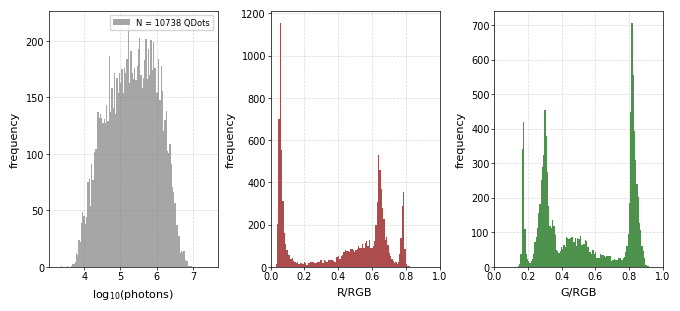

In [38]:
folder = image_folder
sm_db = pd.read_hdf(os.path.join(folder, 'MixD_single_molecules.h5'))
sf_db = pd.read_hdf(os.path.join(folder, 'MixD_single_molecules.h5'))
pa_db = pd.read_hdf(os.path.join(folder, 'MixD_single_molecules.h5'))

fig, axs = plotter.two_column_plot(ncols=3)


bins = np.histogram_bin_edges(np.log10(sm_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sm_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)', color='gray', 
                                label='N = '+str(len(sm_db['photons'].to_numpy()))+' QDots')
axs[0].set_ylabel('frequency', fontsize=8)

bins = np.histogram_bin_edges(sm_db['A_R'].to_numpy(), 'sqrt')
axs[1] = plotter.histogram_plot(axs[1], sm_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
axs[1].set_xlabel('R/RGB', fontsize=8)
axs[1].set_ylabel('frequency', fontsize=8)

bins = np.histogram_bin_edges(sm_db['A_G'].to_numpy(), 'sqrt')
axs[2] = plotter.histogram_plot(axs[2], sm_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')
axs[2].set_xlabel('G/RGB', fontsize=8)
axs[2].set_ylabel('frequency', fontsize=8)

axs[0].set_xlim([0.9*np.min(np.log10(sm_db['photons'])), 1.1*np.max(np.log10(sm_db['photons']))])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/dye_discrimination/QDOT647N/'
#plt.savefig(os.path.join(folder, 'Dye_Mixtures_perMolecule.svg'), dpi=600, format='svg')

plt.show()

In [ ]:
def sigma_to_confidence(sigma):
    """
    Convert sigma level to confidence level for 2D Gaussian.

    For a 2D Gaussian, the probability within radius r*sigma is:
    P(r) = 1 - exp(-r²/2)

    Args:
        sigma: Sigma level (e.g., 1.0 for 1σ)

    Returns:
        Confidence level (0-1)
    """
    return 1.0 - np.exp(-sigma**2 / 2)


In [ ]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260121_QDotIndividuals"
localisation_files = H_F.file_search(image_folder, ".h5", "_single_molecules")
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260113_QDotIndividuals"
localisation_files = np.hstack([localisation_files, H_F.file_search(image_folder, ".h5", "_single_molecules")])
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260112_QDotIndividuals"
localisation_files = np.hstack([localisation_files, H_F.file_search(image_folder, ".h5", "_single_molecules")])
localisation_files = np.sort(localisation_files)

In [ ]:
localisation_files

In [ ]:
dots = np.array(['QDot_525', 'QDot_565', 'QDot_585', 'QDot_605', 'QDot_655', 'QDot_700', 'QDot_800'])

In [ ]:
sigma_levels = [0.5, 1, 1.5, 2, 2.5]
confidence_levels = [sigma_to_confidence(s) for s in sigma_levels]

print(f"\nSigma to confidence conversion:")
for sigma, conf in zip(sigma_levels, confidence_levels):
    print(f"  {sigma:.1f}σ → {conf:.3f} ({conf*100:.1f}% confidence)")

# Create ternary plot
print("\nCreating ternary plot...")
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='ternary')

# Set labels
ax.set_tlabel('Blue (B)')
ax.set_llabel('Red (R)')
ax.set_rlabel('Green (G)')
ax.set_title('RGB Color Distribution with KDE Contours', fontsize=14, pad=20)

# Plot KDE contours for each dataset
colors = ["#cc566a",
"#ca6b39",
"#a7993f",
"#5ba85f",
"#629cce",
"#7b68ca",
"#c360ac"]

labels = dots

for i, dot in enumerate(dots):
    dataset = pd.read_hdf([x for x in localisation_files if dot in x][0])
    R = dataset['A_R'].to_numpy()
    G = dataset['A_G'].to_numpy()
    B = dataset['A_B'].to_numpy()
    if dot == 'QDot_655':
        levels = [0.1, 0.25, 0.95]
    else:
        levels = [0.1, 0.25, 0.5, 0.75, 0.9]
    plotter.plot_ternary_kde_contours(
            ax, R, G, B,
            color=colors[i],
            label=dot.replace('_', ''),
            levels=levels,  # Now fixed to use non-zero KDE values!
            bandwidth=0.05,  # Fixed bandwidth for tight clusters
            linewidths=[0.5, 0.75, 1, 1.25, 1.5][::-1],
            alpha=0.7
        )
    choices = np.random.randint(low=0, high=len(R), size=1000)
    R = R[choices]
    G = G[choices]
    B = B[choices]
    
    # Plot KDE contours using PlottingBase method

    # Add scatter points (optional, small and transparent)
    #ax.scatter(R, G, B, c=colors[i], s=3, alpha=0.1, rasterized=True, label=dot.replace('_', ' '))
ax.legend(loc='upper left', fontsize=6)
ax.grid(True, alpha=0.3)

#folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260121_QDotIndividuals'
#plt.savefig(os.path.join(folder, 'Subsampled_Ternary_KDE.svg'), dpi=600, format='svg')
plt.show()

In [ ]:
folder = image_folder
sm_db = pd.read_hdf(os.path.join(folder, 'QDot_605_single_molecules.h5'))
sf_db = pd.read_hdf(os.path.join(folder, 'QDot_605_single_frames.h5'))
pa_db = pd.read_hdf(os.path.join(folder, 'QDot_605_photon_accumulation.h5'))

fig, axs = plotter.two_column_plot(ncols=3)

highphoton_db = sm_db[sm_db['photons'] > 1e6]

bins = np.histogram_bin_edges(np.log10(sm_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sm_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)', color='gray', 
                                alpha=0.1,
                                label='N = '+str(len(sm_db['photons'].to_numpy()))+' QDots')


axs[0] = plotter.histogram_plot(axs[0], np.log10(highphoton_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)', color='gray', 
                                label='N = '+str(len(sm_db['photons'].to_numpy()))+' QDots')

axs[0].set_ylabel('frequency', fontsize=8)

bins = np.histogram_bin_edges(sm_db['A_R'].to_numpy(), 'sqrt')
axs[1] = plotter.histogram_plot(axs[1], sm_db['A_R'], bins, 
                                color='darkred',
                                alpha=0.1,
                                density=True,
                               xlabel='R/RGB')

axs[1] = plotter.histogram_plot(axs[1], highphoton_db['A_R'], bins, 
                                color='red',
                                density=True,
                                alpha=0.75,
                               xlabel='R/RGB')

axs[1].set_xlabel('R/RGB', fontsize=8)
axs[1].set_ylabel('frequency', fontsize=8)

bins = np.histogram_bin_edges(sm_db['A_G'].to_numpy(), 'sqrt')
axs[2] = plotter.histogram_plot(axs[2], sm_db['A_G'], bins, 
                                color='darkgreen',
                                alpha=0.1,
                                density=True,
                               xlabel='G/RGB')

axs[2] = plotter.histogram_plot(axs[2], highphoton_db['A_G'], bins, 
                                color='green',
                                density=True,
                                alpha=0.75,
                               xlabel='G/RGB')

axs[2].set_xlabel('G/RGB', fontsize=8)
axs[2].set_ylabel('frequency', fontsize=8)

axs[0].set_xlim([0.9*np.min(np.log10(sm_db['photons'])), 1.1*np.max(np.log10(sm_db['photons']))])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/dye_discrimination/QDOT647N/'
#plt.savefig(os.path.join(folder, 'Dye_Mixtures_perMolecule.svg'), dpi=600, format='svg')

plt.show()

In [ ]:
fig, axs = plotter.two_column_plot(ncols=3)


bins = np.histogram_bin_edges(np.log10(sf_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sf_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)', color='gray', label='N = '+str(len(sf_db['photons'].to_numpy()))+' localisations')

axs[0].set_xlabel('photons', fontsize=8)
axs[0].set_ylabel('frequency', fontsize=8)

bins = np.histogram_bin_edges(sf_db['A_R'].to_numpy(), 'fd')
axs[1] = plotter.histogram_plot(axs[1], sf_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
axs[1].set_xlabel('R/RGB', fontsize=8)
axs[1].set_ylabel('frequency', fontsize=8)

bins = np.histogram_bin_edges(sf_db['A_G'].to_numpy(), 'fd')
axs[2] = plotter.histogram_plot(axs[2], sf_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')
axs[2].set_xlabel('G/RGB', fontsize=8)
axs[2].set_ylabel('frequency', fontsize=8)

axs[0].set_xlim([2, np.max(np.log10(sf_db['photons']))])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/dye_discrimination/QDOT647N/'
#plt.savefig(os.path.join(folder, 'QDOT_Mixture_perFrame.svg'), dpi=600, format='svg')

plt.show()

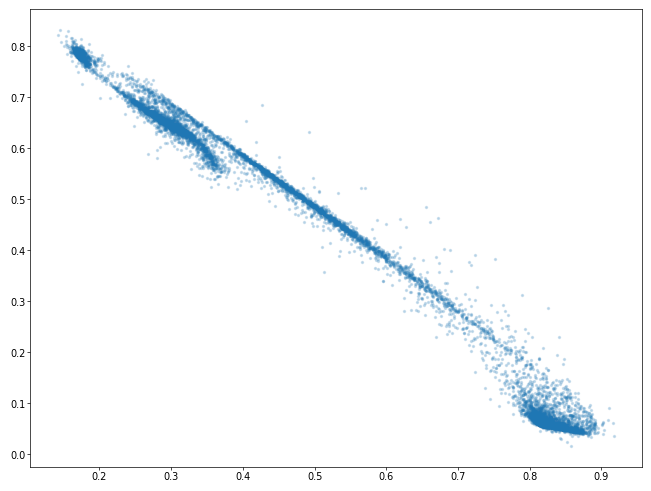

In [39]:
plt.scatter(sm_db['A_G'].to_numpy(), sm_db['A_R'].to_numpy(), s=2, alpha=0.2);

plt.show(block=False)

In [ ]:
fig, axs = plotter.create_subplots(ncols=3, figsize=(9, 3))

filter_levels = np.logspace(3, 6, 21)

cs = ["#ac4f5e",
"#d74154",
"#c8562b",
"#de916c",
"#92672e",
"#d79433",
"#b3ae61",
"#b9b934",
"#66732a",
"#6e9d38",
"#58bd51",
"#3b8251",
"#5fc091",
"#49b9d3",
"#6983c8",
"#7160cc",
"#c26fd4",
"#98528e",
"#d24395",
"#e086ae"]


alpha_gradient = np.linspace(1, 0.2, 20)

for i in np.arange(len(filter_levels[:-1])):
    filtered = pa_db[
          (pa_db['photons_accumulated'] >= filter_levels[i]) &
          (pa_db['photons_accumulated'] < filter_levels[i+1])
      ]
    bins = np.histogram_bin_edges(np.log10(filtered['photons_accumulated'].to_numpy()), 'fd')
    axs[0] = plotter.histogram_plot(axs[0], np.log10(filtered['photons_accumulated']), bins, density=False, 
                                    color=cs[i], xlabel=r'log$_{10}$(photons)',
                                   alpha=alpha_gradient[i])
    axs[0].set_xlabel('photons', fontsize=8)
    axs[0].set_ylabel('frequency', fontsize=8)

    
    bins = np.histogram_bin_edges(filtered['A_R'].to_numpy(), 'fd')
    axs[1] = plotter.histogram_plot(axs[1], filtered['A_R'], bins, 
                                    alpha=alpha_gradient[i], color=cs[i],
                                   xlabel='R/RGB')
    axs[1].set_xlabel('R/RGB', fontsize=8)
    axs[1].set_ylabel('frequency', fontsize=8)
    
    bins = np.histogram_bin_edges(filtered['A_G'].to_numpy(), 'fd')
    axs[2] = plotter.histogram_plot(axs[2], filtered['A_G'], bins, 
                                    alpha=alpha_gradient[i], color=cs[i],
                                   xlabel='G/RGB')
    axs[2].set_xlabel('G/RGB', fontsize=8)
    axs[2].set_ylabel('frequency', fontsize=8)

axs[0].set_xlim([3, 6])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/dye_discrimination/QDOT647N/'
plt.savefig(os.path.join(folder, 'Dye_Mixtures_vs_Photons.svg'), dpi=600, format='svg')
plt.show()

In [ ]:
plt.hist(sm_db['A_G'][sm_db['photons'] > 25000][sm_db['A_G'] > 0.15], 100);
plt.show()

In [ ]:
# Step 1: Extract reference means from highest-photon data (Analytical Approach)
# Uses all molecules to establish fixed mean positions
# These means represent the true dye RGB signatures (signal), not measurement noise

fixed_means, ref_db, gmm = SM_E.extract_reference_means(
    sm_db[sm_db['photons'] > 25000][sm_db['A_G'] > 0.15],
    reference_photon_threshold=None,
    n_components=2,
    covariance_type="full",
    fit_type="MLE",
    verbose=True
)

print(f"\nFixed means extracted from {len(ref_db)} high-photon molecules:")
print(f"  Component 0: A_R={fixed_means[0,0]:.4f}, A_G={fixed_means[0,1]:.4f}")
print(f"  Component 1: A_R={fixed_means[1,0]:.4f}, A_G={fixed_means[1,1]:.4f}")
print(f"\nThese means will be held fixed while analyzing noise at lower photon levels.")

In [ ]:
# Step 2: Analytical misidentification analysis across photon bins
# For each photon bin:
#   1. Fit covariances with fixed means (M-estimators) - characterizes measurement noise robustly
#   2. Analytically calculate overlap/error rates from fitted distributions
# This separates signal (means) from noise (covariances) for better interpretation

photon_bins = np.logspace(np.log10(500), np.log10(200000), 20)  # 2k to 200k photons, 20 bins

summary_analytical = SM_E.analyze_photon_dependent_misidentification_analytical(
    pa_db,
    fixed_means,
    ref_db,
    photon_bins,
    reference_covariances=gmm.covariances_,  # Use reference covariances from high-photon fit
    use_earliest_entry=True,
    estimator_type="tukey",  # Use Tukey bisquare (aggressive outlier down-weighting)
    max_iter=20,  # Maximum iterations for M-estimator re-weighting
    n_mc_samples=100000,  # Monte Carlo samples for analytical calculation
    verbose=True
)

print(f"\nAnalytical analysis complete:")
print(f"  Summary: {len(summary_analytical)} photon bins")
print(f"  Accuracy range: {summary_analytical['overall_accuracy'].min():.3f} - {summary_analytical['overall_accuracy'].max():.3f}")

In [ ]:
summary_analytical

In [ ]:
fig, axs = plotter.create_subplots(figsize=(7, 4))

axs = plotter.scatter_plot(axs, 0.5*(summary_analytical['photon_bin_min']+summary_analytical['photon_bin_max']), 100*(summary_analytical['overall_error_rate']),
                          xlabel='photons', ylabel=r'% dye misidentification', color='white',
                          label='error rate')

axs.set_ylim([0.001, 50])
axs.hlines(y=5, xmin=500, xmax=200000, ls='--', lw=0.75, color='red', label=r'5% error')
axs.hlines(y=1, xmin=500, xmax=200000, ls='--', lw=0.75, color='#FFBF00', label=r'1% error')
axs.hlines(y=0.1, xmin=500, xmax=200000, ls='--', lw=0.75, color='green', label=r'0.1% error')
axs.set_xlabel('photons',  fontsize=8)
axs.set_ylabel('% dye misidentification', fontsize=8)
axs.set_xlim([500, 2e4])

axs.set_yscale('log')
axs.set_xscale('log')
axs.legend(loc='best')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/dye_discrimination/QDOT647N/'
plt.savefig(os.path.join(folder, 'Dye_Error_Rate.svg'), dpi=600, format='svg')

plt.show()

In [ ]:
fig, axs = plotter.create_subplots(figsize=(1, 1))

spectra = S_F.get_dye_or_filter_data(wavelength=wavelength, names=['ATTO 647N', 'Qdot 800'])
axs = plotter.line_plot(ax=axs, x=wavelength, y=spectra[0, :], color='red')
axs = plotter.line_plot(ax=axs, x=wavelength, y=spectra[1, :], color='white', xlabel='wavelength/nm', ylabel='fluo./norm.')

axs.set_xlim([600, 900])
axs.set_ylim([0, 0.02])
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Group Meeting/20251201/fig/multicolour_camera/dye_discrimination/QDOT647N/'
plt.savefig(os.path.join(folder, 'ATTO647N_QDOT800.svg'), dpi=600, format='svg')


In [ ]:
# Diagnostic: Examine posterior distributions to understand outlier sensitivity
# Let's look at a specific photon bin to understand the fitting quality

# Choose a mid-range photon bin for analysis (e.g., around 10k photons)
test_bin_min = 10000
test_bin_max = 14000

# Filter data for this photon bin
bin_molecules = pa_db[
    (pa_db['molecular_index'].isin(ref_db['molecular_index'])) &
    (pa_db['photons_accumulated'] >= test_bin_min) &
    (pa_db['photons_accumulated'] < test_bin_max)
]

print(f"Analyzing photon bin: [{test_bin_min:,} - {test_bin_max:,}) photons")
print(f"Number of molecules: {len(bin_molecules)}")

# Extract A_R, A_G data
X = bin_molecules[['A_R', 'A_G']].values

# Get reference covariances from high-photon fit
ref_covariances = gmm.covariances_
print(f"\nReference covariances from high-photon fit (>25k photons):")
for k in range(len(fixed_means)):
    det = np.linalg.det(ref_covariances[k])
    print(f"  Component {k}: det={det:.6f}")
    print(f"    {ref_covariances[k]}")

# Fit covariances with fixed means using EM (standard approach)
covs_em, weights_em, converged_em = SM_E.fit_covariances_fixed_means(
    X, fixed_means, fit_type="EM", max_iter=100, verbose=True
)

print(f"\nFitted covariances at {test_bin_min:,}-{test_bin_max:,} photons (EM):")
for k in range(len(fixed_means)):
    det = np.linalg.det(covs_em[k])
    print(f"  Component {k}: det={det:.6f}")
    print(f"    {covs_em[k]}")

# Calculate determinant ratios
print(f"\nDeterminant ratios (low-photon / high-photon):")
for k in range(len(fixed_means)):
    ratio = np.linalg.det(covs_em[k]) / np.linalg.det(ref_covariances[k])
    print(f"  Component {k}: {ratio:.1f}x larger")

# Calculate posterior probabilities (responsibilities)
from scipy.stats import multivariate_normal
n_components = len(fixed_means)
responsibilities = np.zeros((len(X), n_components))

for k in range(n_components):
    responsibilities[:, k] = weights_em[k] * multivariate_normal.pdf(
        X, mean=fixed_means[k], cov=covs_em[k]
    )

# Normalize responsibilities
responsibilities /= responsibilities.sum(axis=1, keepdims=True)

# Get maximum posterior probability for each point
max_posteriors = responsibilities.max(axis=1)

# Visualize posterior distribution
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Histogram of maximum posterior probabilities
axs[0, 0].hist(max_posteriors, bins=50, edgecolor='black')
axs[0, 0].axvline(0.8, color='red', linestyle='--', label='80% confidence')
axs[0, 0].set_xlabel('Maximum Posterior Probability')
axs[0, 0].set_ylabel('Count')
axs[0, 0].set_title('Distribution of Assignment Confidence')
axs[0, 0].legend()

# Plot 2: Data colored by confidence
scatter = axs[0, 1].scatter(X[:, 0], X[:, 1], c=max_posteriors, cmap='viridis', 
                            s=10, alpha=0.5)
axs[0, 1].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20, 
               label='Fixed means')
axs[0, 1].set_xlabel('A_R')
axs[0, 1].set_ylabel('A_G')
axs[0, 1].set_title('Data colored by posterior confidence')
axs[0, 1].legend()
plt.colorbar(scatter, ax=axs[0, 1], label='Max posterior')

# Plot 3: Reference covariances from high-photon fit
from matplotlib.patches import Ellipse
def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
    """Plot covariance ellipse"""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellipse)

axs[0, 2].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, 2], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'Ref cov {k}')
axs[0, 2].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[0, 2].set_xlabel('A_R')
axs[0, 2].set_ylabel('A_G')
axs[0, 2].set_title(f'Reference Covariances (high-photon fit)')
axs[0, 2].legend()

# Plot 4: Fitted covariances (EM) - showing the problem
axs[1, 0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[1, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM cov {k}')
axs[1, 0].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[1, 0].set_xlabel('A_R')
axs[1, 0].set_ylabel('A_G')
axs[1, 0].set_title('Fitted Covariances (EM) - Current Method')
axs[1, 0].legend()

# Plot 5: Overlay both for comparison
axs[1, 1].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    # Reference (dashed)
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[1, 1], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, linestyle='--', label=f'Ref {k}')
    # Fitted (solid)
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[1, 1], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM {k}')
axs[1, 1].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[1, 1].set_xlabel('A_R')
axs[1, 1].set_ylabel('A_G')
axs[1, 1].set_title('Comparison: Reference (dashed) vs EM (solid)')
axs[1, 1].legend()

# Plot 6: Identify potential outliers using Mahalanobis distance from reference
outliers_mask = np.zeros(len(X), dtype=bool)
mahal_threshold = 3.0  # 3-sigma threshold

for i, x in enumerate(X):
    # Find closest component
    dists = []
    for k in range(n_components):
        diff = x - fixed_means[k]
        inv_cov = np.linalg.inv(ref_covariances[k])
        mahal = np.sqrt(diff @ inv_cov @ diff)
        dists.append(mahal)
    
    min_dist = min(dists)
    if min_dist > mahal_threshold:
        outliers_mask[i] = True

axs[1, 2].scatter(X[~outliers_mask, 0], X[~outliers_mask, 1], alpha=0.3, s=10, c='blue',
                  label=f'Inliers (<{mahal_threshold}σ from ref)')
axs[1, 2].scatter(X[outliers_mask, 0], X[outliers_mask, 1], alpha=0.8, s=30, c='red',
                  label=f'Outliers (>{mahal_threshold}σ from ref)')
for k in range(n_components):
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[1, 2], n_std=mahal_threshold,
                     edgecolor='green', facecolor='none', 
                     linewidth=2, linestyle='--')
axs[1, 2].plot(fixed_means[:, 0], fixed_means[:, 1], 'k*', markersize=20,
               label='Fixed means')
axs[1, 2].set_xlabel('A_R')
axs[1, 2].set_ylabel('A_G')
axs[1, 2].set_title(f'Outlier Detection using Mahalanobis (n={outliers_mask.sum()})')
axs[1, 2].legend()

plt.show()

# Statistics
print(f"\nPosterior Statistics:")
print(f"  Mean max posterior: {max_posteriors.mean():.3f}")
print(f"  Median max posterior: {np.median(max_posteriors):.3f}")
print(f"  % with >90% confidence: {100*(max_posteriors > 0.9).sum()/len(max_posteriors):.1f}%")
print(f"  % with >80% confidence: {100*(max_posteriors > 0.8).sum()/len(max_posteriors):.1f}%")
print(f"  % with <50% confidence: {100*(max_posteriors < 0.5).sum()/len(max_posteriors):.1f}%")
print(f"\nOutlier Statistics (Mahalanobis distance from reference):")
print(f"  % outliers (>{mahal_threshold}σ): {100*outliers_mask.sum()/len(outliers_mask):.1f}%")

In [ ]:
# Test robust fitting method and compare with standard EM
print("="*60)
print("Testing Robust Fitting Method")
print("="*60)

# Test with different Mahalanobis thresholds
thresholds = [2.0, 3.0, 4.0]

fig, axs = plt.subplots(2, len(thresholds)+1, figsize=(6*(len(thresholds)+1), 12))

# Plot 0: Standard EM (for comparison)
axs[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[0, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM {k}')
    # Also show reference as dashed
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=1, linestyle='--', alpha=0.5)
axs[0, 0].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20)
axs[0, 0].set_xlabel('A_R')
axs[0, 0].set_ylabel('A_G')
axs[0, 0].set_title('Standard EM\n(dashed = reference)')
axs[0, 0].legend()

# Determinant comparison
dets_em = [np.linalg.det(covs_em[k]) for k in range(n_components)]
dets_ref = [np.linalg.det(ref_covariances[k]) for k in range(n_components)]
ratios_em = [dets_em[k] / dets_ref[k] for k in range(n_components)]

axs[1, 0].bar([f'Comp {k}' for k in range(n_components)], ratios_em, color=['blue', 'orange'])
axs[1, 0].axhline(1.0, color='green', linestyle='--', label='Reference')
axs[1, 0].set_ylabel('Det ratio (fitted / ref)')
axs[1, 0].set_title('Standard EM: Covariance Size Ratio')
axs[1, 0].legend()

# Test robust fitting with different thresholds
for i, threshold in enumerate(thresholds, 1):
    print(f"\nTesting threshold = {threshold}σ:")
    
    covs_robust, weights_robust, converged_robust = SM_E.fit_covariances_fixed_means_robust(
        X, fixed_means, 
        reference_covariances=ref_covariances,
        mahalanobis_threshold=threshold,
        max_iter=10,
        verbose=True
    )
    
    # Plot fitted covariances
    axs[0, i].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
    for k in range(n_components):
        plot_cov_ellipse(covs_robust[k], fixed_means[k], axs[0, i], n_std=2.0,
                         edgecolor=['blue', 'orange'][k], facecolor='none', 
                         linewidth=2, label=f'Robust {k}')
        # Also show reference as dashed
        plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, i], n_std=2.0,
                         edgecolor=['blue', 'orange'][k], facecolor='none', 
                         linewidth=1, linestyle='--', alpha=0.5)
    axs[0, i].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20)
    axs[0, i].set_xlabel('A_R')
    axs[0, i].set_ylabel('A_G')
    axs[0, i].set_title(f'Robust ({threshold}σ threshold)\n(dashed = reference)')
    axs[0, i].legend()
    
    # Determinant comparison
    dets_robust = [np.linalg.det(covs_robust[k]) for k in range(n_components)]
    ratios_robust = [dets_robust[k] / dets_ref[k] for k in range(n_components)]
    
    axs[1, i].bar([f'Comp {k}' for k in range(n_components)], ratios_robust, color=['blue', 'orange'])
    axs[1, i].axhline(1.0, color='green', linestyle='--', label='Reference')
    axs[1, i].set_ylabel('Det ratio (fitted / ref)')
    axs[1, i].set_title(f'Robust ({threshold}σ): Covariance Size Ratio')
    axs[1, i].legend()

plt.show()

print("\n" + "="*60)
print("Summary: Determinant Ratios (Fitted / Reference)")
print("="*60)
print(f"{'Method':<20} {'Component 0':<15} {'Component 1':<15}")
print("-"*60)
print(f"{'Standard EM':<20} {ratios_em[0]:<15.2f} {ratios_em[1]:<15.2f}")
for threshold in thresholds:
    covs_robust, _, _ = SM_E.fit_covariances_fixed_means_robust(
        X, fixed_means, ref_covariances, threshold, max_iter=10, verbose=False
    )
    dets = [np.linalg.det(covs_robust[k]) for k in range(n_components)]
    ratios = [dets[k] / dets_ref[k] for k in range(n_components)]
    print(f"{'Robust (' + str(threshold) + 'σ)':<20} {ratios[0]:<15.2f} {ratios[1]:<15.2f}")

print("\nIdeal ratio should be close to 1.0 (matching reference covariances)")
print("Lower ratios = tighter fit, less influenced by outliers")

In [ ]:
# different implementation: take the highest photon data and get the centres, then fit the widths at each photon bin.
# Then use the fact the data are normally distributed to calculate the analytical false positive rates.

# this is an example of linking molecules with HDBSCAN ###

In [ ]:
single_molecule_database, single_frame_database = SM_E.extract_single_molecules_HDBSCAN(
    localisation_files,
    min_cluster_size=min_cluster_size,
    max_localization_error=max_localization_error,
    min_photons=min_photons,
    max_photons=max_photons,
)

# this is an example of linking molecules with DBSCAN

In [ ]:
single_molecule_database, single_frame_database = SM_E.extract_single_molecules_DBSCAN(
    pd.read_hdf(localisation_files[0]),
    min_cluster_size=min_cluster_size,
    max_localization_error=max_localization_error,Dye
    min_photons=min_photons,
    chi_val=chi_val,
    max_photons=max_photons,
)

In [ ]:
molecules_to_remove = single_molecule_database['molecular_index'][single_molecule_database['A_R'] > 0.8]

In [ ]:
single_molecule_database = single_molecule_database[single_molecule_database['A_R'] < 0.8]
single_frame_database =

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])



plt.hist((single_molecule_database['A_R']), 200);
plt.show()

# this is an example of linking molecules sequentially

In [ ]:
extract_single_molecules_linked = SM_E.extract_single_molecules_linked(
    localisation_files,
    max_distance=max_distance,
    max_localization_error=max_localization_error,
    min_photons=min_photons,
    max_photons=max_photons,
)